## Road Surface Classification Using Smartphone Accelerometer Data

## Team Members
- Samuel Cramer

## GitHub Repository URL
https://github.com/scramer27/road_surface_classification/

## Abstract

Potholes are a problem for both cities and drivers, causing billions of dollars of damage to vehicles every year. While just repairing potholes is relatively inexpensive, identifying their locations is currently very costly. Manually evaluating road surfaces is a lengthy, labor-intensive, process, and some using modern techniques such as using LIDAR and advanced cameras can be rather expensive. In this project, we have developed machine learning models in order to help detect potholes and normal road surfaces using 3-axis smartphone accelerometer data, as well as provided an interactive map of the aforementioned surface types. We compared baseline methods, logistic regression models, and a 1D convolutional neural network (CNN) trained on time-series accelerometer windows, with labels indicating whether each window corresponds to a pothole or normal surface. Our results show that model complexity improved pothole detection performance, as engineered features in a logistic regression model and CNN methods significantly improved our metrics when compared to simple baselines or a logistic regression model on raw data. Results were largely evaluated on F1-score and accuracy of each of our four models.

## Introduction

Maintaining high-quality road infrastucture is an essential aspect of municipal operations and public safety. Potholes, however, are road defects can form from many causes such as moisture, traffic, and poor installation. However, perhaps the most relevant to my current residence, Vermont, would be the freeze-thaw damages that is made especially apparent in the mud season from April to May. Depending on severity, damage caused by potholes can range from a small bump to bent wheels to event multi-vehicle accidents. In fact, potholes and other similar road defects in the United States can cost drivers upwards of $3 billion in annual repairs. While potholes can be cost effective to repair, at roughly $200 each, detecting potholes remains difficult and costly. Many municipalities still rely on manual reporting or inspection, while other options such as Vermont's Automated Road Analyzer (ARAN) make use of expensive lazer technology. 

Smartphone-based detection, however, may offer a great alternative. While few workers are tasked with road maintenance, nearly every driver carries a device with an accelerometer and GPS. There have been many others who have experimented within this realm. For one, Eriksson et al. (2008) created the pothole patrol system by utilizing a collection of vehicles equipped with 3-axis accelerometers and GPS, in order to map high-confidence road anomaly detections, using clustering techniques. Furthermore, Kulkarni et al. (2014) utilized accelerometers and GPS on an Android operating system, along with a neural network to achieve high performance (over 90% accuracy), setting effective acceleration threshold values on the x-axis and z-axis. Finally, Mednis et al. (2011) were able to tune a Z-axis acceleration algorithm under real-world driving conditions, with TP rates up to 92%. Our work attempts to build on the aforementioned, collecting our own labeled dataset, performing preprocessing, and then comparing four levels of model complexity on the same dataset, using a 1D CNN as our most advanced machine learning technique.

Being able to perform automatic road surface classification is extremely beneficial. By detecting and geolocating potholes automatically, all road defects of a road network can be identified more easily. If road workers were able to have this at their disposal, they would be able to mindlessly drive over road surfaces while their phone captures the geolocations of imperfections and normal roads alike, while if "crowd-sourced" by a city's residents, the quantity of data would speed up the detection process and lessen the strain on city workers and budgets. 

Note: References are located at the bottom of the notebook

## Values Statement
The primary users of this project would be governments, municipalities, and contractors who could use the automated pothole detection system to be able to locate and prioritize road repairs more efficiently, with less time and money than traditional surveying or high-tech sensing via lasers or LIDAR. Furthermore, invididuals could use the system to inform in advance poor road conditions to be avoided. However, many people including drivers, cyclists, and pedestrians will all benefit from safer road surfaces, as reduced road hazards reduce risk of injury and damage to property. In addition, the developers of the technology will benefit from it, as they may receive financial compensation from those who use the detection software.

Some people may be harmed from this technology on the basic level, when the model fails to make a correct prediction, money and time may be wasted on sending resources out to fix a pothole which may not exist (which is accounted for in the cost matrix below ), and there may be the risk of injury, damage, and other ill effects should a pothole be misclassified as a normal road segment (which is accounted for in the cost matrix below, with the double the severity of the opposite wrong prediction due to physical risks to humans and property). Furthermore, if this technology should replace manual surveying or high-tech methods as discussed above, workers in those fields and/or companies may face economic hardships. Additionally, if the geolocations aren't effectively anonymized, the locations of a person's workplace or home may be exposed to a third-party. Finally, one potential equity concern is that if the technology is deployed privately instead of publically, wealthier areas may have more resources to act on the improved road surface data, whereas lower-income areas may not have the resources to fix certain areas of the road, thus widening the infrastructure gap between commjnities. 

When it comes to my personal motivation, I really wanted to be able to integrate my some of my greatest passions into a project, which include cars, transit networks, maps, and hardware. Thus, when given the opportunity to take my own data, customize a project to my liking, and implement a machine learning pipeline, I thought that conducting a project like this would be perfect. Furthermore, I enjoyed the process of self-collecting data, as real-world challenges such as human error, lacking GPS data, labeling data, and the challenges of synchronizing data made me tested by my ML project to think outside the box. As a fan of old Volvos, suspension issues are something that I deal with frequently, as do many other Americans, due to potholes, so being able to tackle a problem that I actively face was an additional appeal.

When it comes to equity and balance, I believe that this technology would improve the world, in that better-identifying poor roads has the potential to make road infrastructure universally better. If we are able to deploy this on a large scale, form a robust model, and ensure that these mapping and classification efforts of poor roads are supported by public sector funding and leadership, it could make workers' jobs easier, save drivers from accidents and repairs, and make all people safer when using the road.

## Data

Driving data was taken across four driving sessions, primarily concentrated on Route 125 in Vermont, and Interstate 93 in Massachusetts, using three devices in a vehicle. One smartphone was mounted in a car, running Physics Toolbox to sample accelerometer data at 100Hz, another smartphone was used running Open GPX Tracker in order to capture real-time GPS coordinates, and a laptop kept track of labels during each drive, with my volunteer operating the labeler.py script in order to mark pothole and normal road surfaces. Drives were conducted largely on highways, with the same vehicle, a 2007 Volvo XC70, with consistent payload weight and road types throughout testing. The smartphone running Open GPX was secured to the passanger seat with tape.

Each session produced three files, an acceleration CSV with ax, ay, az, and atotal values, mapped to time elapsed, a CSV with event timestamps, and a GPX file that contained GPS coordinates with timestamps. The pipeline.py script allowed us to first trim 5 seconds at the beginning and end of the timespan shared by all three data sources for each test drive, to account for experiment start and end noise. It also helped us to merge the three data forms in terms of local time, extract fixed windows of acceleration data points around each event label, and removes the contaminated events in which potholes and normal labels occur close to each other, in order to avoid cross-class training problems. GPS points were assigned to acceleration samples by finding the closest available datapoint that existed within a 2-second tolerance. 

Nine dataset configurations were created in this process, with three different window sizes (A: 3.5 seconds, B: 2.5 seconds, C: 1.5 seconds) and three different contamination thresholds (1: 2.5 seconds, 2: 3.0 seconds, 3: 3.5 seconds). In this report, we focus on configuration C3, which is the shortest time window with the most stringent contamination filter, so as to limit normal road data bleediing into pothole windows as well as to limit the chance that two labels would be assigned to the same road segment. To account for the relative reaction time gap between feeling a pothole and manual input, pothole windows were biased before the actual label timestamps, to better capture the full pothole waveform, whereas normal windows were centered around the label timestamps, as reaction time wasn't as significant of a factor. However, normal windows and pothole windows were kept the same size, to account for the architecture of a 1D CNN, following a similar methodology to our previous work in classifying birdcalls using a 1D CNN. Additionally, incomplete accelerometer samples were dropped from the dataset.

Originally, this project sought to perform a multiclass classification by including speedbumps as a third class, but with less than 10 speedbump events collected across all four test drives, there was insufficient training data, so those labels were dropped in favor of performing a binary classification.

The components of data that were used as features were the four acceleration channels from the accelerometer, ax, ay, az, and atotal, and the binary label of Normal or Pothole is our target. Below, we import the requisite libraries necessary for this notebook, and load the C3 dataset, demonstrate its structure, and provide a visualization of the geographic distribution of labels via an html map located in the maps directory.

To set up for an extension, an unsupervised dataset was created in the pipeline.py script as well, which dropped all datapoints without GPS data. Though an algorithm such as clustering was not implemented in this project, we see this as an easy future extension.

Note: Due to a well-documented issue with the Folium library in VS Code, the interactive map has been saved in the maps directory, instead of populating the map as a cell output, which is known to cause issues.

#### Import Libraries
First, we import the necessary python libraries, as well as classes and functions created to help support our 4-model comparison.

In [230]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import os
import random
from torch.utils.data import DataLoader
from torchinfo import summary
from src.models import *
from src.helpers import *


#### Device Selection
Then, we use the most effecient device available, which in my case was MPS, printing the device that is used.

In [231]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


#### Constants 
Below are our constants, including the acceleration feature names that represent the different columns of our raw data, classes, which represent our labels for each raw data window, and window lengths, which is a dictionary that maps the letter of a configuration to how many samples were taken @100Hz during that window.

In [232]:
ACCELS = ['ax', 'ay', 'az', 'atotal']
CLASSES = ['NORMAL', 'POTHOLE']
WINDOW_LENGTHS = {'A': 350, 'B': 250, 'C': 150}

#### Cost Matrix
Finally, the cost matrix below assigns differing costs to different types of errors. False negatives, missing a pothole, is assigned a cost of 400, while a false positive, marking a pothole that didn't exist, is assigned a cost of 200. Accurate classifications, true positives and true negatives, cost 0. This is done as missing a pothole can caused far more damage than the cost of accidentally sending a team to repair a pothole that doesn' need repairing, as one may correspond with vehicle damage, accidents, or injuries, while the other is just wasted labor time. Accurate classifications are assigned no cost as sending a repair crew to fix a pothole is the goal of this model, and not fixing a normal road is also a goal of this model, and thus neither costs extra beyond what a municipality should already be doing.

-----------------| Predicted Normal       | Predicted Pothole

Actually Normal  | True Normal=0                  |  False Positive = 200     

Actually Pothole | False Negative = 400   |  True Normal=0 

In [233]:
cost_matrix = torch.tensor([[0, 200.0], [400.0, 0]], dtype=torch.float32).to(device)
cost_matrix

tensor([[  0., 200.],
        [400.,   0.]], device='mps:0')

#### Load Dataframe

Here we load the dataframe from the CSV file, and display its format

In [234]:
df = pd.read_csv('data/intermediary_data/supervised_C3.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nClasses:")
print(df.groupby('event_id')['label'].first().value_counts())
df.head()

Shape: (102169, 13)

Columns: ['event_id', 'label', 'test', 'elapsed_sec', 'wall_clock', 'ax', 'ay', 'az', 'atotal', 'lat', 'lon', 'elevation', 'label_time']

Classes:
label
NORMAL     533
POTHOLE    147
Name: count, dtype: int64


,event_id,label,test,elapsed_sec,wall_clock,ax,ay,az,atotal,lat,lon,elevation,label_time
0,test_1_NORMAL_224942647231,NORMAL,test_1,22.901,2026-04-19 22:49:41.901000+00:00,0.94,-0.58,0.95,1.46,44.00799,-73.180151,131.981021,2026-04-19 22:49:42.647231+00:00
1,test_1_NORMAL_224942647231,NORMAL,test_1,22.911,2026-04-19 22:49:41.911000+00:00,0.73,0.06,0.45,0.86,44.00799,-73.180151,131.981021,2026-04-19 22:49:42.647231+00:00
2,test_1_NORMAL_224942647231,NORMAL,test_1,22.921,2026-04-19 22:49:41.921000+00:00,0.77,-0.46,0.63,1.09,44.00799,-73.180151,131.981021,2026-04-19 22:49:42.647231+00:00
3,test_1_NORMAL_224942647231,NORMAL,test_1,22.931,2026-04-19 22:49:41.931000+00:00,1.06,-0.52,0.71,1.38,44.00799,-73.180151,131.981021,2026-04-19 22:49:42.647231+00:00
4,test_1_NORMAL_224942647231,NORMAL,test_1,22.941,2026-04-19 22:49:41.941000+00:00,0.84,-0.03,0.70,1.09,44.00799,-73.180151,131.981021,2026-04-19 22:49:42.647231+00:00


#### Mapping Our Data
This code allows us to assign one GPS point to each driving event, removing entries with missing GPS points, finding the first valid sample of each different event, and then creating a Folium (external python library) map in order to find the locations and labels of each event, showing red markers for potholes and blue markers for normal roads. The map is saved as an HTML file in the maps directory, as unfortunately VSCode didn't allow for map background display without restarting the application, which is a known issue.

In [235]:
# find one row per event
events = df.dropna(subset=['lat', 'lon']) # drop no gps rows
events = events.groupby('event_id').first().reset_index() # find first row of each event

m = folium.Map(location=[events['lat'].mean(), events['lon'].mean()], zoom_start=10) # create a map

for _, row in events.iterrows(): # loop through locations
    color = 'red' if row['label'] == 'POTHOLE' else 'blue'
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color=color,
        fill=True,
        popup=row['label']
    ).add_to(m)

# places the folium map into the map directory
map_dir = 'maps'
if not os.path.exists(map_dir):
    os.makedirs(map_dir)
    print(f"Created directory: {map_dir}")
map_path = os.path.join(map_dir, 'road_map_C3.html')
m.save(map_path)
print("Map of data has been saved")


Map of data has been saved


## Our Approach

We used four levels of model complexity on the C3 configuration (1.5 second data windows and 3.5 second contamination thresholds) of our dataset, in increasing level of complexity. Training was completed locally on a M2 Macbook Air in Google Colab, using Apple's MPS. The target is a binary classification (label) of Normal (0) or Pothole (1). The features were four columns corresponding to 100Hz samples of ax, ay, az, and atot. 

L1: Our baseline, in which we always predict the label of an even to be Normal, ignoring our acceleration features entirely. This is our naive approach, and sets our bottom line accuracy of roughly 80%, which is high due to the class imbalance, but there is zero recall on potholes and high expected cost.

L2: A step up, with Logistic Regression on Raw Windows. This is the raw accelerometer window flattened into a feature vector and then passed into the logistic regression model. The threshold is tuned on the validation set to make a decision boundary which minimizes the expected cost. The loss funciton is binary cross-entropy (BCE) and the optimizer used is Adam.

L3: A similar approach to L2, with Logistic Regression on Engineered Features. Here we use summary statistics (mean, std, max, min) on each of the four channels to create a 16-dimensional feature vector. This allows us to better capture the acceleration peaks and changes that are representative of a pothole. Once again, the threshold is tuned on the validation set to make a decision boundary which minimizes the expected cost. The loss funciton is binary cross-entropy (BCE) and the optimizer used is Adam, using a nearly identical methodology as L2, save for the input features. However, this model likely is better than L2, due to the ability of summary statistics to better capture the characteristic "pothole spikes" in the signal of the data.

L4: A 1D Convolutional Neural Network. A 1D CNN (using CONV1D, RELU, MAXPOOL1D four times, followed by a linear layer at the end) that learns the features themselves from raw accelerometer signals within each labeled window. We use Adam as our optimizer and BCE as our loss function, and use checkpointing on the best F1 score (rather than accuracy, which favors balanced classes) over 100 epochs. Our training scheme used batching for efficiency purposes. Random time-shift is used to augment our data, wrapping data around within the same window during the training phase. The model was trained using train_cnn.py, and the checkpoint we found is located here in the root.

All models use 80/20 train/validation data split in order to prevent leackage of data, and we make evaluations using accuracy, F1, and expected cost primarily, and recall and precision less explicitly. We used a cost matrix to penalize missed potholes (FN, 400) twice as heavily as false alarms (FP, 200). TN and TP were left as 0 cost, as they are correct classifications. We know that the cost of hitting a pothole that is undetected is about twice as large as sending an individual to a site to conduct a repair that isn't necessary, which is the reasoning for the costs assigned above.

Two significant data collection limitations are of note. First, human reaction time gaps during labeling of pothole events may have slightly been offset from the optimal labeling time, which, may make our data windows suboptimal. Second, as labeling errors may have occured, as potholes may have been marked as normal or vice versa, there may be some more sources of error in this dataset. The asymmetric pothole window, which biases towards time before the label timestamp, attempts to compensate for this reaction time gap. The plot below shows the effect of the event windows chosen.


#### Time Window Visualization

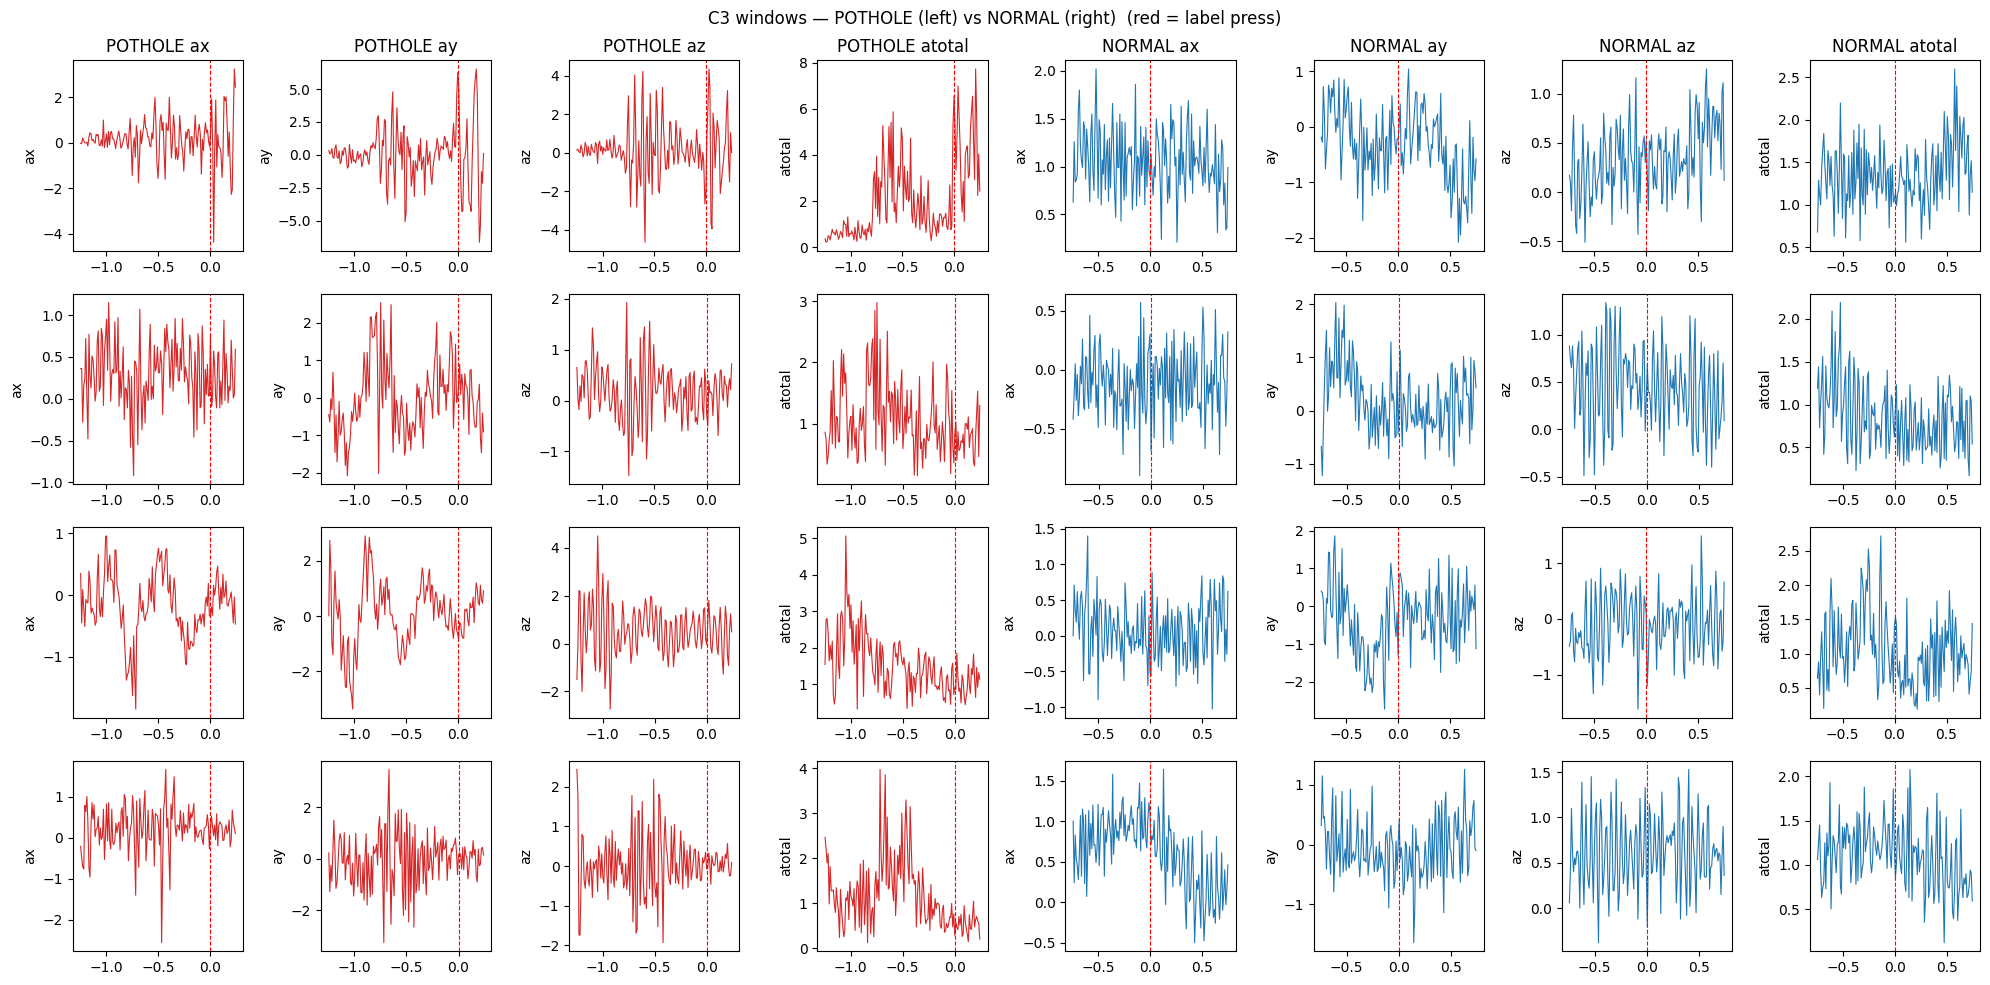

In [236]:
NUM_WINDOWS = 4 # how many pothole and normal pairs to plot

# find event IDs corresponding with each road type
pothole_ids = list(df[df['label'] == 'POTHOLE']['event_id'].unique())
normal_ids  = list(df[df['label'] == 'NORMAL']['event_id'].unique())

# randomly choose IDs
random.seed(42) # keeps results consistent for the report
random_potholes = random.sample(pothole_ids, min(NUM_WINDOWS, len(pothole_ids)))
random_normals  = random.sample(normal_ids,  min(NUM_WINDOWS, len(normal_ids)))

# asked gemini to "how to make clean subplots , 4 x 8 grid"
fig, axes = plt.subplots(NUM_WINDOWS, 8, figsize=(20, 2.5 * NUM_WINDOWS))

fig.suptitle(
    "C3 windows — POTHOLE (left) vs NORMAL (right)  (red = label press)",
    fontsize=12
)

# plot each event pair
for i in range(NUM_WINDOWS):

    # grab pothole rows for this event and compute time relative to label press
    pothole_window = df[df['event_id'] == random_potholes[i]].copy()
    pothole_label_time = pd.to_datetime(pothole_window['label_time'].iloc[0], utc=True, format='mixed')
    pothole_window['t'] = (pd.to_datetime(pothole_window['wall_clock'], utc=True, format='mixed') - pothole_label_time).dt.total_seconds()

    # grab normal rows for this event and compute time relative to label press
    normal_window = df[df['event_id'] == random_normals[i]].copy()
    normal_label_time = pd.to_datetime(normal_window['label_time'].iloc[0], utc=True, format='mixed')
    normal_window['t'] = (pd.to_datetime(normal_window['wall_clock'], utc=True, format='mixed') - normal_label_time).dt.total_seconds()

    # plot pothole axes
    for j, col in enumerate(['ax', 'ay', 'az', 'atotal']):
        axes[i][j].plot(pothole_window['t'], pothole_window[col], linewidth=0.8, color='tab:red')
        axes[i][j].axvline(0, color='red', linewidth=0.8, linestyle='--') # red line at label press
        axes[i][j].set_ylabel(col)
        if i == 0:
            axes[i][j].set_title(f"POTHOLE {col}")

    # plot normal axes
    for j, col in enumerate(['ax', 'ay', 'az', 'atotal']):
        axes[i][j + 4].plot(normal_window['t'], normal_window[col], linewidth=0.8, color='tab:blue')
        axes[i][j + 4].axvline(0, color='red', linewidth=0.8, linestyle='--') # red line at label press
        axes[i][j + 4].set_ylabel(col)
        if i == 0:
            axes[i][j + 4].set_title(f"NORMAL {col}")

plt.tight_layout()
plt.show()

Here we store our results:

In [237]:
results = []

### Level 1: Base Rate Model (Always Normal)

In [238]:
torch.manual_seed(42)
np.random.seed(42)

y_rows = [CLASSES.index(group['label'].iloc[0]) for _, group in df.groupby('event_id')]
y = torch.tensor(y_rows, dtype=torch.float32).to(device)

idx = torch.randperm(len(y))
split = int(0.8 * len(y))
y_train, y_val = y[idx[:split]], y[idx[split:]]

print("Baseline (always predict NORMAL)\n")
for split_name, y_true in [("Train", y_train), ("Val", y_val)]:
    y_pred = torch.zeros(len(y_true)).to(device)
    cm = confusion_matrix(y_pred, y_true)
    p  = precision(cm)
    r  = recall(cm)
    f1 = f1_score(p, r)
    acc = accuracy(y_pred, y_true)
    ec = expected_cost(cm, cost_matrix)
    print(f"  {split_name} Confusion Matrix:\n{cm.cpu()}")
    print(f"  Accuracy:      {acc:.3f}")
    print(f"  Expected Cost: {ec:.3f}")
    print(f"  Precision:     {p:.3f}")
    print(f"  Recall:        {r:.3f}")
    print(f"  F1:            {f1:.3f}\n")
results.append(("L1: Baseline", f1, acc, ec, cm))


Baseline (always predict NORMAL)

  Train Confusion Matrix:
tensor([[433.,   0.],
        [111.,   0.]])
  Accuracy:      0.796
  Expected Cost: 81.618
  Precision:     0.000
  Recall:        0.000
  F1:            0.000

  Val Confusion Matrix:
tensor([[100.,   0.],
        [ 36.,   0.]])
  Accuracy:      0.735
  Expected Cost: 105.882
  Precision:     0.000
  Recall:        0.000
  F1:            0.000



### Level 2 & 3: Logistic Model (Raw Data & Engineered Features)

In [239]:
torch.manual_seed(42)
np.random.seed(42)

T = torch.linspace(0, 1, 101).to(device)
window_len = WINDOW_LENGTHS['C']

levels = {
    "L2: Logistic Regression (raw window)": flatten_window,
    "L3: Logistic Regression (engineered features)": engineer_features,
}

# extract labels
y_rows = [CLASSES.index(group['label'].iloc[0]) for _, group in df.groupby('event_id')]
y = torch.tensor(y_rows, dtype=torch.float32).to(device)

# train/val split 80/20
idx = torch.randperm(len(y))
split_vals = int(0.8 * len(y))

for level_name, feature_fn in levels.items():

    # feature extraction
    X_rows = []
    for event, group in df.groupby('event_id'):
        samples = group[ACCELS][:window_len].values
        X_rows.append(feature_fn(samples))

    X = torch.tensor(np.array(X_rows), dtype=torch.float32).to(device)

    # normalize X
    X = (X - X.mean(dim=0)) / (X.std(dim=0) + 1e-8)

    X_training, X_validation = X[idx[:split_vals]], X[idx[split_vals:]]
    y_training, y_validation = y[idx[:split_vals]].reshape(-1, 1), y[idx[split_vals:]].reshape(-1, 1)

    # training loop
    model = LogisticModel(X_training.shape[1], device)
    opt = torch.optim.Adam([model.w], lr=1e-3)

    for epoch in range(1000):
        q = model.forward(X_training)
        loss = binary_cross_entropy(q, y_training)
        opt.zero_grad()
        loss.backward()
        opt.step()

    # get probabilities for validation set
    q_validation = model.forward(X_validation).detach()

    # compute costs and accuracies over threshold values, adapted from lecture
    costs, accuracies = costs_and_accuracies(q_validation, y_validation, cost_matrix, T)
    best_t_cost = T[torch.argmin(torch.tensor(costs))].item()
    best_t_acc = T[torch.argmax(torch.tensor(accuracies))].item()

    print(f"\n{level_name} — C3")
    print(f"  best expected cost = {min(costs):.3f} at t={best_t_cost:.2f}")
    print(f"  best accuracy      = {max(accuracies):.3f} at t={best_t_acc:.2f}")

    # evaluate at best threshold
    for split_name, X_s, y_s in [("Train", X_training, y_training), ("Val", X_validation, y_validation)]:
        y_pred = (model.forward(X_s) >= best_t_cost).float()
        cm = confusion_matrix(y_pred, y_s)
        p  = precision(cm)
        r  = recall(cm)
        f1 = f1_score(p, r)

        acc = accuracy(y_pred, y_s)
        ec = expected_cost(cm, cost_matrix)

        print(f"  {split_name} Confusion Matrix:\n{cm.cpu()}")
        print(f"  Accuracy:      {acc:.3f}")
        print(f"  Expected Cost: {ec:.3f}")
        print(f"  Precision:     {p:.3f}")
        print(f"  Recall:        {r:.3f}")
        print(f"  F1:            {f1:.3f}\n")

    results.append((level_name, f1, acc, ec, cm))


L2: Logistic Regression (raw window) — C3
  best expected cost = 39.706 at t=0.97
  best accuracy      = 0.882 at t=0.99
  Train Confusion Matrix:
tensor([[433.,   0.],
        [ 12.,  99.]])
  Accuracy:      0.978
  Expected Cost: 8.824
  Precision:     1.000
  Recall:        0.892
  F1:            0.943

  Val Confusion Matrix:
tensor([[91.,  9.],
        [ 9., 27.]])
  Accuracy:      0.868
  Expected Cost: 39.706
  Precision:     0.750
  Recall:        0.750
  F1:            0.750


L3: Logistic Regression (engineered features) — C3
  best expected cost = 22.059 at t=0.80
  best accuracy      = 0.919 at t=0.80
  Train Confusion Matrix:
tensor([[423.,  10.],
        [ 12.,  99.]])
  Accuracy:      0.960
  Expected Cost: 12.500
  Precision:     0.908
  Recall:        0.892
  F1:            0.900

  Val Confusion Matrix:
tensor([[93.,  7.],
        [ 4., 32.]])
  Accuracy:      0.919
  Expected Cost: 22.059
  Precision:     0.821
  Recall:        0.889
  F1:            0.853



### Level 4: 1D CNN

In [240]:
window_length = WINDOW_LENGTHS['C']

torch.manual_seed(42)
np.random.seed(42)

# split events
event_ids = df['event_id'].unique()
idx = torch.randperm(len(event_ids))
split = int(0.8 * len(idx))

train_ids = event_ids[idx[:split].numpy()]
val_ids   = event_ids[idx[split:].numpy()]

# create dataloaders, using dataset objects like miniproject
train_loader = DataLoader(RoadSurfaceDataset(df[df['event_id'].isin(train_ids)], window_length, device, augment=True),
                          batch_size=16, shuffle=True)
val_loader   = DataLoader(RoadSurfaceDataset(df[df['event_id'].isin(val_ids)], window_length, device, augment=False),
                          batch_size=16, shuffle=False)

# load best saved model instead of retraining
model = RoadSurfaceCNN().to(device)
model.load_state_dict(torch.load('best_model_C3.pt', map_location=device))

print("CNN — C3")
print(summary(model, input_size=next(iter(train_loader))[0].shape, device=device))

# final metrics on train and val sets
for split_name, loader in [("Train", train_loader), ("Val", val_loader)]:
    acc, ec, f1, cm = evaluate(model, loader, cost_matrix)
    p = precision(cm)
    r = recall(cm)
    print(f"\n  {split_name} Confusion Matrix:\n{cm.cpu()}")
    print(f"  Accuracy:      {acc:.3f}")
    print(f"  Expected Cost: {ec:.3f}")
    print(f"  Precision:     {p:.3f}")
    print(f"  Recall:        {r:.3f}")
    print(f"  F1:            {f1:.3f}")

results.append(("L4: 1D CNN", f1, acc, ec, cm))


CNN — C3
Layer (type:depth-idx)                   Output Shape              Param #
RoadSurfaceCNN                           [16, 1]                   --
├─Sequential: 1-1                        [16, 1]                   --
│    └─Conv1d: 2-1                       [16, 16, 150]             208
│    └─ReLU: 2-2                         [16, 16, 150]             --
│    └─MaxPool1d: 2-3                    [16, 16, 75]              --
│    └─Conv1d: 2-4                       [16, 32, 75]              1,568
│    └─ReLU: 2-5                         [16, 32, 75]              --
│    └─MaxPool1d: 2-6                    [16, 32, 37]              --
│    └─Conv1d: 2-7                       [16, 64, 37]              6,208
│    └─ReLU: 2-8                         [16, 64, 37]              --
│    └─MaxPool1d: 2-9                    [16, 64, 18]              --
│    └─Conv1d: 2-10                      [16, 128, 18]             24,704
│    └─ReLU: 2-11                        [16, 128, 18]           

### Summary Statistics of All Four Models

In [241]:
for model_name, f1, acc, cost, cm in results:
    print(f"Model name:{model_name:<30} \n| F1 Score:{f1:.3f}  | Accuracy:{acc:.3f}  | Expected Cost{cost:.3f}")
    print(f"Confusion Matrix: \n{cm}")

Model name:L1: Baseline                   
| F1 Score:0.000  | Accuracy:0.735  | Expected Cost105.882
Confusion Matrix: 
tensor([[100.,   0.],
        [ 36.,   0.]], device='mps:0')
Model name:L2: Logistic Regression (raw window) 
| F1 Score:0.750  | Accuracy:0.868  | Expected Cost39.706
Confusion Matrix: 
tensor([[91.,  9.],
        [ 9., 27.]], device='mps:0')
Model name:L3: Logistic Regression (engineered features) 
| F1 Score:0.853  | Accuracy:0.919  | Expected Cost22.059
Confusion Matrix: 
tensor([[93.,  7.],
        [ 4., 32.]], device='mps:0')
Model name:L4: 1D CNN                     
| F1 Score:0.941  | Accuracy:0.971  | Expected Cost5.882
Confusion Matrix: 
tensor([[100.,   4.],
        [  0.,  32.]], device='mps:0')


## Results

The results show a definite improvement and gradual progress among the four model levels. With the base model, our F1 score is the worst it could be at 0.0, but achieves baseline accuracy of 73.5%, and has high expected cost of 105.882, especially due to the many potholes missed, which corresponds well to our cost matrix. The L2 overfits fairly badly, with inferior validation performance compared to our training performance, and has relatively low F1 score of 0.750 and minimal accuracy improvement to 86.8%, 13% more than our base rate, presumably due to the flattened window being difficult for our model to learn the signal. L2's expected cost was 39.706, a major improvement over the base rate. L3 is a substantial improvement, as when we changed the features to summary stats, we also capture a great deal of the “peaking” nature of acceleration during a pothole event, leading us to achieve an improved F1 score of 0.853 with an accuracy of 0.919 and an expected cost of 22.059, showing that this superior model is on average going to cost us less due to mistakes in classification than the previous two models. The 1D CNN has the best performance, achieving minimal expected costs of 5.882, high accuracy of 97.1%, and high F1 score of 0.941, showing that learning features from the raw signal has a high upside.

,F1,Accuracy,Expected Cost
Model,,,
L1: Baseline,0.000,0.735,105.882
L2: Logistic Regression (raw window),0.750,0.868,39.706
L3: Logistic Regression (engineered features),0.853,0.919,22.059
L4: 1D CNN,0.941,0.971,5.882


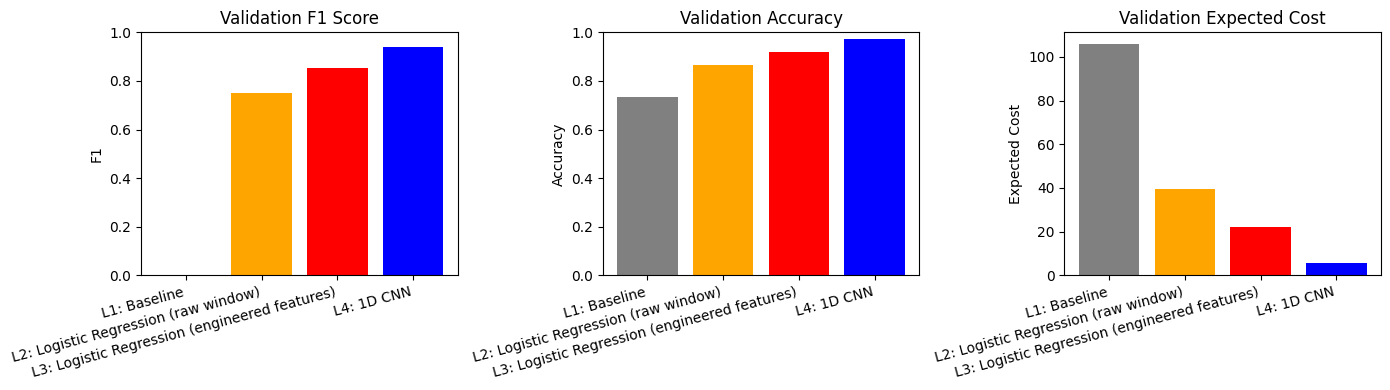

In [ ]:
# show summary stats
summary = pd.DataFrame([
    {'Model': name, 'F1': f1, 'Accuracy': acc, 'Expected Cost': ec}
    for name, f1, acc, ec, cm in results
])
display(summary.set_index('Model').style.format('{:.3f}'))

# bar charts for f1, accuracy, expected cost
names = [r[0] for r in results]
f1s   = [r[1].cpu().item() if torch.is_tensor(r[1]) else float(r[1]) for r in results] # fixed error where still was in tensor format
accs  = [r[2].cpu().item() if torch.is_tensor(r[2]) else float(r[2]) for r in results] # fixed error where still was in tensor format
costs = [float(r[3]) for r in results]
colors = ['gray', 'orange', 'red', 'blue']

# set up plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(names, f1s, color=colors)
axes[0].set_title('Validation F1 Score')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('F1')

axes[1].bar(names, accs, color=colors)
axes[1].set_title('Validation Accuracy')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Accuracy')

axes[2].bar(names, costs, color=colors)
axes[2].set_title('Validation Expected Cost')
axes[2].set_ylabel('Expected Cost')

for ax in axes:
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=15, ha='right')

plt.tight_layout()
plt.show()

## Concluding Discussion

Our project had high degrees of success. It demonstrated that by using smartphone accelerometer data, we can reliably classify road events. The 1D CNN achieved extremely high F1 scores on configuration C3, which confirms that the learned features were able to outperform our raw data and hand-engineered features in our more basic logistic regression model. High degrees of accuracy were also achieved in both the hand-engineered logistic regression model and in the 1D CNN, which seems to be consistent with previous work, such as that of Kulkarni et al. (2014), which used achieved ~92% accuracy with a neural network, compared to our result of ~97% with the 1D CNN and around 91% with the logistic regression using engineered features. 

With more time, we would explore several different extensions. First, implementing additional data augmentations such as overlapping windows with padding could increase training data quantities, and adding jerk may contribute as an additional feature. Second, the unsupervised dataset was created but not used, so creating some sort of model that takes advantage of clustering may provide further classifying performance without the need for manual labeling, which can be inaccurate. Third, having more drives over more road surfaces and would potentially create a more robust model, and open up the door for multi-class classification, which could have enough labeled data to train our model for speedbumps and other desired road surfaces. Testing with different vehicles and phone mounting schemes may also yield more widely applicable results. Finally, creating a full-fledged mobile app that incorporates the model as well as the data taking process would improve furhter tests.

## Contributions

This was an individual project. I researched adequate methods of capturing GPS and Acceleration Data, and created a labeler script (labeler.py) in order to mark sections of road off as potholes or normal sections. I conducted the test drives to use the labeler script, but I required the help of a volunteer in order to press keys corresponding with labels on my laptop while I drove. I then wrote a data pipeline (pipeline.py) in order to clean up the data collection windows to create centralized spreadsheets that reflect the three sources of data in one place. I then made a visualizer (plots.py) and ran a baseline test (a model that picks the most common class), and two levels (engineering and non-engineered features ) of a logistic regression model, in order to gauge which data configuration best demonstrated the prediction gains of each successively "better" model. Then, I trained three models on our best data configuration, C3, and developed our comparisons, map visualization, "blog post" writing, and this final report.

### References

Chodrow, Phil. CSCI 451: Machine Learning. Middlebury College, Spring 2026.

Eriksson, Jakob, et al. “The Pothole Patrol: Using a Mobile Sensor Network for Road Surface Monitoring.” Proceedings of the 6th International Conference on Mobile Systems, Applications, and Services, 2008.

Kulkarni, Aniket, et al. “Pothole Detection System Using Machine Learning on Android.” International Journal of Emerging Technology and Advanced Engineering, vol. 4, no. 7, 2014, pp. 360–364.

Mednis, Artis, et al. “Real Time Pothole Detection Using Android Smartphones with Accelerometers.” 2011 International Conference on Distributed Computing in Sensor Systems and Workshops (DCOSS), IEEE, 2011.